***Módulos a Importar***

In [15]:
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Punto 1

0. Funciones a Utilizar

In [91]:
# Sabiendo theta1 y theta2, calcula la posicion x y y del punto 1 (Direct Kinematics)

def lista_posiciones(lista_theta1, lista_theta2):

  lista_posx_p1 = []
  lista_posy_p1 = []

  for elemento_unico in range(len(lista_theta1)):
    theta1_unico = lista_theta1[elemento_unico]
    theta2_unico = lista_theta2[elemento_unico]
    lista_posx_p1.append(f_posicionx_p1(theta1_unico, theta2_unico))
    lista_posy_p1.append(f_posiciony_p1(theta1_unico, theta2_unico))

  return lista_posx_p1, lista_posy_p1

In [92]:
# Sabiendo las coordenadas X y Y de los 3 puntos de interés, graficar su movimiento en el espacio

def graficar_puntos(x1, y1, x2, y2, x3, y3):
    plt.figure(figsize=(8, 8))

    plt.plot(x1, y1, label="Punto 1")
    plt.plot(x2, y2, label="Punto 2")
    plt.plot(x3, y3, label="Punto 3")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trayectoria de los 3 puntos")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.show()

In [93]:


def graficar_puntos(x1, y1, x2, y2, x3, y3):
    plt.figure(figsize=(8, 8))

    plt.plot(x1, y1, label="Punto 1")
    plt.plot(x2, y2, label="Punto 2")
    plt.plot(x3, y3, label="Punto 3")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Trayectoria de los 3 puntos")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.show()

1. Definición del Modelo

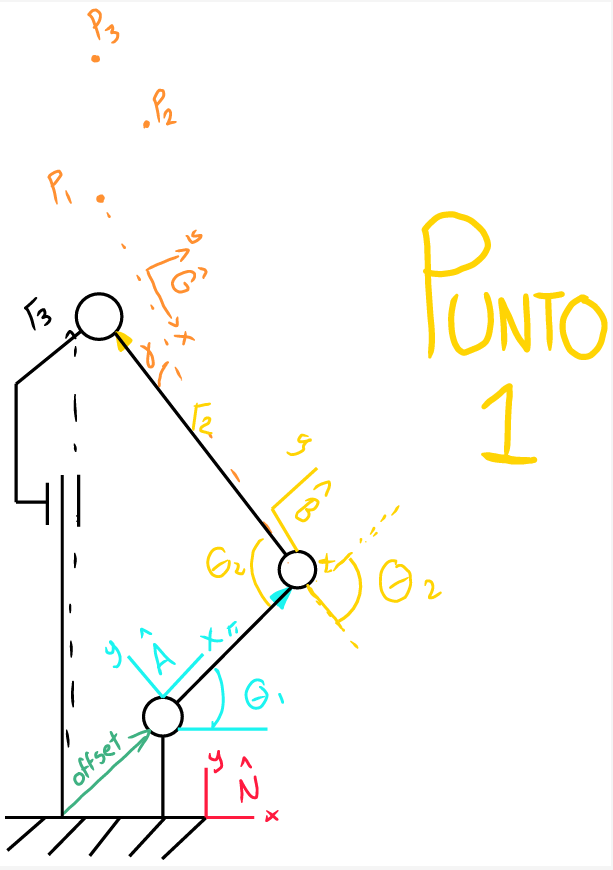

In [107]:
# 1. Definición de Variables
theta, theta2 = dynamicsymbols('theta theta2')
l1, l2, l3_min, s, px, py = sp.symbols('l1 l2 l3_min s px py')

# s == Que tanto se esta expandiendo desde su punto de compresión maximo (entre 0 y 20
# print)

# 2. Definición de Marcos
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))
B = A.orientnew('B', 'Axis', (-theta2, A.z))

# 3. Definición de Medidas y Vectores
l3 = l3_min + s
offset = px*N.x + py*N.y
r1 = l1*A.x
r2 = -l2*B.x
r3 = l3*N.y

# 4. Definición de Ecuaciones y Loop
loop = r1 + r2 - r3 -offset
eq_x = loop.dot(N.x)
eq_y = loop.dot(N.y)
eq = [eq_x, eq_y]

# 5. Conversión a función numérica
fun_eq = sp.lambdify((theta, theta2, l1, l2, l3_min, s, px, py), eq, "numpy")

# 6. Fijación de Valores
val = {
    l1: 30,
    l2: 30,
    l3_min: 30,
    px: 10,
    py: 5,
}
s_val = np.linspace(0, 20, 100)

# 7. Aproach Numérico (hallar theta1 y theta2)

estimacion_angulos = [np.radians(45), np.radians(90)]
theta1_sol = []
theta2_sol = []

for s_num in s_val:
  regleta = lambda v: fun_eq(*v, val[l1],val[l2], val[l3_min],s_num,val[px],val[py])
  solu=fsolve(regleta,estimacion_angulos)
  theta1_sol.append(solu[0])
  theta2_sol.append(solu[1])
  estimacion_angulos=solu


print(theta1_sol)

[np.float64(0.3735726061346202), np.float64(0.3791689667368741), np.float64(0.38476391310247826), np.float64(0.3903578716690549), np.float64(0.39595126868827213), np.float64(0.4015445304606573), np.float64(0.4071380835727231), np.float64(0.4127323551367031), np.float64(0.4183277730332381), np.float64(0.42392476615737396), np.float64(0.4295237646682475), np.float64(0.4351252002428447), np.float64(0.4407295063342363), np.float64(0.4463371184347184), np.float64(0.45194847434429314), np.float64(0.4575640144449563), np.float64(0.4631841819812776), np.float64(0.4688094233477806), np.float64(0.47444018838366236), np.float64(0.4800769306754141), np.float64(0.48572010786794184), np.float64(0.4913701819848157), np.float64(0.49702761975831405), np.float64(0.5026928929699669), np.float64(0.5083664788023475), np.float64(0.5140488602029071), np.float64(0.5197405262606934), np.float64(0.5254419725968541), np.float64(0.5311537017698817), np.float64(0.5368762236966186), np.float64(0.5426100560901124), 

Plus. Gráfica Ángulos

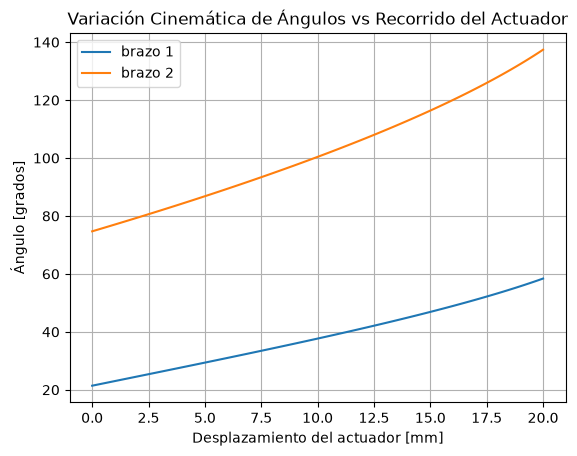

<class 'list'>
<class 'list'>


In [108]:
plt.plot(s_val, np.degrees(theta1_sol), label=r'brazo 1')
plt.plot(s_val, np.degrees(theta2_sol), label=r'brazo 2')
plt.xlabel('Desplazamiento del actuador [mm]')
plt.ylabel('Ángulo [grados]')
plt.title('Variación Cinemática de Ángulos vs Recorrido del Actuador')
plt.grid()
plt.legend()
plt.show()



print(type(theta1_sol))
print(type(theta2_sol))

B. Trayectoria en el Espacio de los Puntos

In [109]:
dp1 = sp.symbols('dp1')
gamma1 = sp.symbols('gamma1')
valores_gamma = {gamma1:np.deg2rad(35), dp1:45}

vector_origen_b = offset + r1

G = A.orientnew('G', 'Axis', (-theta2 - gamma1, A.z))

vector_p1 = (vector_origen_b + dp1 *-G.x).express(N).subs(val).subs(valores_gamma)

f_posicionx_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.x),"numpy")
f_posiciony_p1 = sp.lambdify((theta,theta2),vector_p1.dot(N.y),"numpy")


posicionesx_p1, posicionesy_p1 = lista_posiciones(theta1_sol,theta2_sol)

vp1_p2 = [-5,15]
vp1_p3 = [0,30]

posicionesx_p2 = [xi + vp1_p2[0] for xi in posicionesx_p1]
posicionesy_p2 = [yi + vp1_p2[1] for yi in posicionesy_p1]
posicionesx_p3 = [xi + vp1_p3[0] for xi in posicionesx_p1]
posicionesy_p3 = [yi + vp1_p3[1] for yi in posicionesy_p1]

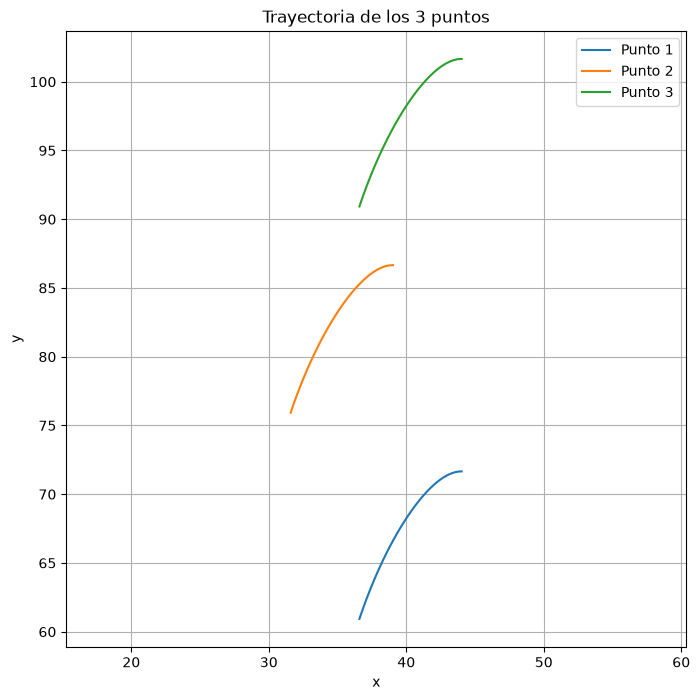

In [110]:
graficar_puntos(posicionesx_p1, posicionesy_p1, posicionesx_p2, posicionesy_p2, posicionesx_p3, posicionesy_p3)